In [1]:
import pandas as pd

week1_tracking = pd.read_csv("/Users/alecxszhang/Desktop/Stat 390/Data/tracking_week_1.csv")
players = pd.read_csv("/Users/alecxszhang/Desktop/Stat 390/Data/players.csv")
plays = pd.read_csv("/Users/alecxszhang/Desktop/Stat 390/Data/plays.csv")
player_play = pd.read_csv("/Users/alecxszhang/Desktop/Stat 390/Data/player_play.csv")
games = pd.read_csv("/Users/alecxszhang/Desktop/Stat 390/Data/games.csv")

In [2]:
#week1_tracking["event"].value_counts()

In [3]:
games.columns

Index(['gameId', 'season', 'week', 'gameDate', 'gameTimeEastern',
       'homeTeamAbbr', 'visitorTeamAbbr', 'homeFinalScore',
       'visitorFinalScore'],
      dtype='str')

In [4]:
player_play.head()
player_play.columns

Index(['gameId', 'playId', 'nflId', 'teamAbbr', 'hadRushAttempt',
       'rushingYards', 'hadDropback', 'passingYards', 'sackYardsAsOffense',
       'hadPassReception', 'receivingYards', 'wasTargettedReceiver',
       'yardageGainedAfterTheCatch', 'fumbles', 'fumbleLost',
       'fumbleOutOfBounds', 'assistedTackle', 'forcedFumbleAsDefense',
       'halfSackYardsAsDefense', 'passDefensed', 'quarterbackHit',
       'sackYardsAsDefense', 'safetyAsDefense', 'soloTackle', 'tackleAssist',
       'tackleForALoss', 'tackleForALossYardage', 'hadInterception',
       'interceptionYards', 'fumbleRecoveries', 'fumbleRecoveryYards',
       'penaltyYards', 'penaltyNames', 'wasInitialPassRusher',
       'causedPressure', 'timeToPressureAsPassRusher',
       'getOffTimeAsPassRusher', 'inMotionAtBallSnap', 'shiftSinceLineset',
       'motionSinceLineset', 'wasRunningRoute', 'routeRan',
       'blockedPlayerNFLId1', 'blockedPlayerNFLId2', 'blockedPlayerNFLId3',
       'pressureAllowedAsBlocker', 'timeT

In [5]:
players.head()

,nflId,height,weight,birthDate,collegeName,position,displayName
0,25511,6-4,225,1977-08-03,Michigan,QB,Tom Brady
1,29550,6-4,328,1982-01-22,Arkansas,T,Jason Peters
2,29851,6-2,225,1983-12-02,California,QB,Aaron Rodgers
3,30842,6-6,267,1984-05-19,UCLA,TE,Marcedes Lewis
4,33084,6-4,217,1985-05-17,Boston College,QB,Matt Ryan


In [6]:
defense = ["OLB", "DE", "DT", "ILB", "FS", "SS", "NT", "MLB", "DB", "LB", "CB", "SAF"]

players["sideofball"] = players["position"].apply(
    lambda pos: "Defense" if pos in defense else "Offense"
)

# Verify
players[["sideofball"]].value_counts().sort_index()

sideofball
Defense       863
Offense       834
Name: count, dtype: int64

In [7]:
week1_tracking = week1_tracking.merge(
    players[["displayName", "sideofball"]],
    on="displayName",
    how="left"
)


In [8]:
plays.columns

Index(['gameId', 'playId', 'playDescription', 'quarter', 'down', 'yardsToGo',
       'possessionTeam', 'defensiveTeam', 'yardlineSide', 'yardlineNumber',
       'gameClock', 'preSnapHomeScore', 'preSnapVisitorScore',
       'playNullifiedByPenalty', 'absoluteYardlineNumber',
       'preSnapHomeTeamWinProbability', 'preSnapVisitorTeamWinProbability',
       'expectedPoints', 'offenseFormation', 'receiverAlignment',
       'playClockAtSnap', 'passResult', 'passLength', 'targetX', 'targetY',
       'playAction', 'dropbackType', 'dropbackDistance', 'passLocationType',
       'timeToThrow', 'timeInTackleBox', 'timeToSack', 'passTippedAtLine',
       'unblockedPressure', 'qbSpike', 'qbKneel', 'qbSneak',
       'rushLocationType', 'penaltyYards', 'prePenaltyYardsGained',
       'yardsGained', 'homeTeamWinProbabilityAdded',
       'visitorTeamWinProbilityAdded', 'expectedPointsAdded', 'isDropback',
       'pff_runConceptPrimary', 'pff_runConceptSecondary', 'pff_runPassOption',
       'pff_pass

In [9]:
plays["offenseFormation"]

0             EMPTY
1             EMPTY
2           SHOTGUN
3           SHOTGUN
4            PISTOL
            ...    
16119       SHOTGUN
16120       SHOTGUN
16121       SHOTGUN
16122    SINGLEBACK
16123    SINGLEBACK
Name: offenseFormation, Length: 16124, dtype: str

In [10]:
plays[(plays['gameId'] == 2022091200) & (plays['playId'] == 64)]

,gameId,playId,playDescription,quarter,down,yardsToGo,possessionTeam,defensiveTeam,yardlineSide,yardlineNumber,...,yardsGained,homeTeamWinProbabilityAdded,visitorTeamWinProbilityAdded,expectedPointsAdded,isDropback,pff_runConceptPrimary,pff_runConceptSecondary,pff_runPassOption,pff_passCoverage,pff_manZone
2677,2022091200,64,(14:54) R.Penny right end to SEA 30 for no gai...,1,1,10,SEA,DEN,SEA,30,...,0,0.004575,-0.004575,-0.362858,False,OUTSIDE ZONE,LEAD;PITCH,0,Cover-3,Zone


In [11]:
presnap_cols = [
    # Game state
    'gameId', 'playId',
    'quarter',
    'down',
    'yardsToGo',
    'gameClock',
    'absoluteYardlineNumber',
    'yardlineSide',
    'yardlineNumber',
    'playClockAtSnap',

    # Score & win probability
    'preSnapHomeScore',
    'preSnapVisitorScore',
    'preSnapHomeTeamWinProbability',
    'preSnapVisitorTeamWinProbability',
    'expectedPoints',           # pre-snap EP, not EPA

    # Teams
    'possessionTeam',
    'defensiveTeam',

    # Formation — known at snap
    'offenseFormation',
    'receiverAlignment',

    # Test results
    'pff_passCoverage', 
    'pff_manZone'
    

    
]

In [12]:
play_context = plays[presnap_cols]

week1_tracking_enhanced = week1_tracking.merge(
    play_context,
    on=['gameId', 'playId'],
    how='left'
)

/var/folders/2p/rhd39m592jv2kqghpzh8s5r40000gp/T/ipykernel_23983/208096467.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap_name)(np.linspace(0.2, 0.9, len(players)))


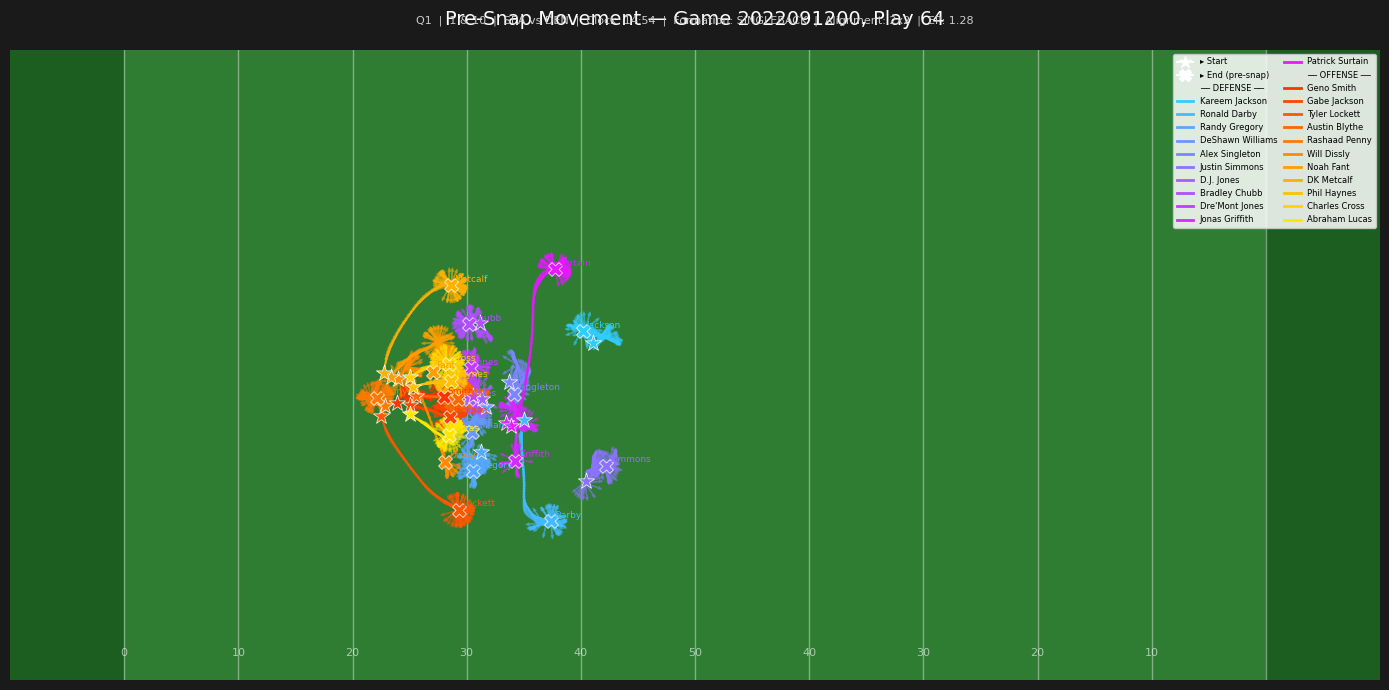

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from matplotlib.lines import Line2D

target_game = 2022091200
target_play = 64

# Filter to BEFORE_SNAP for both sides using enhanced tracking
def get_side_df(side):
    return week1_tracking_enhanced[
        (week1_tracking_enhanced['gameId'] == target_game) &
        (week1_tracking_enhanced['playId'] == target_play) &
        (week1_tracking_enhanced['frameType'] == 'BEFORE_SNAP') &
        (week1_tracking_enhanced['sideofball'] == side)
    ].copy()

defense_df = get_side_df('Defense')
offense_df = get_side_df('Offense')

# Pull play context from any row (same for all rows in this play)
ctx = week1_tracking_enhanced[
    (week1_tracking_enhanced['gameId'] == target_game) &
    (week1_tracking_enhanced['playId'] == target_play)
].iloc[0]

# Assign colors — use two separate colormaps to visually distinguish sides
def assign_colors(df, cmap_name):
    players = df['displayName'].unique()
    colors = plt.cm.get_cmap(cmap_name)(np.linspace(0.2, 0.9, len(players)))
    return dict(zip(players, colors))

defense_colors = assign_colors(defense_df, 'cool')
offense_colors = assign_colors(offense_df, 'autumn')

# Setup the field
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#1a1a1a')
ax.set_facecolor('#2e7d32')

ax.add_patch(patches.Rectangle((0, 0), 120, 53.3, facecolor='#2e7d32', zorder=0))
ax.add_patch(patches.Rectangle((0, 0), 10, 53.3, facecolor='#1b5e20', zorder=0))
ax.add_patch(patches.Rectangle((110, 0), 10, 53.3, facecolor='#1b5e20', zorder=0))

for x in range(10, 120, 10):
    ax.axvline(x, color='white', linewidth=1, alpha=0.4, zorder=1)
for x in range(10, 110, 10):
    yard = x - 10 if x <= 60 else 110 - x
    ax.text(x, 2, str(yard), color='white', fontsize=8, ha='center', alpha=0.6)

def plot_players(df, color_map, zorder_offset=0):
    for name, color in color_map.items():
        p = df[df['displayName'] == name]

        ax.plot(p['x'], p['y'], color=color, linestyle='--', alpha=0.6, linewidth=1.2, zorder=2)

        for _, row in p.iterrows():
            dir_rad = np.deg2rad(90 - row['dir'])
            ax.arrow(row['x'], row['y'],
                     np.cos(dir_rad) * 1.2, np.sin(dir_rad) * 1.2,
                     color=color, alpha=0.5, width=0.03, head_width=0.2, zorder=4)

        ax.scatter(p['x'].iloc[0], p['y'].iloc[0], s=150, color=color,
                   marker='*', edgecolors='white', linewidth=0.5, zorder=7 + zorder_offset)
        ax.scatter(p['x'].iloc[-1], p['y'].iloc[-1], s=100, color=color,
                   marker='X', edgecolors='white', linewidth=0.5, zorder=7 + zorder_offset)

        ax.text(p['x'].iloc[-1] + 0.3, p['y'].iloc[-1] + 0.3, name.split()[-1],
                color=color, fontsize=6.5, zorder=8 + zorder_offset)

plot_players(defense_df, defense_colors)
plot_players(offense_df, offense_colors)

# Legend
legend_elements = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='white', label='▸ Start', markersize=9),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='white', label='▸ End (pre-snap)', markersize=8),
    Line2D([0], [0], color='none', label='── DEFENSE ──'),
] + [Line2D([0], [0], color=defense_colors[n], label=n, linewidth=2) for n in defense_df['displayName'].unique()] + [
    Line2D([0], [0], color='none', label='── OFFENSE ──'),
] + [Line2D([0], [0], color=offense_colors[n], label=n, linewidth=2) for n in offense_df['displayName'].unique()]

ax.legend(handles=legend_elements, loc='upper right', fontsize=6, framealpha=0.85,
          ncol=2, columnspacing=0.8)

# Title + context subtitle from enhanced columns
title = f"Pre-Snap Movement — Game {target_game}, Play {target_play}"
subtitle = (
    f"Q{int(ctx['quarter'])}  |  {int(ctx['down'])} & {int(ctx['yardsToGo'])}  |  "
    f"{ctx['possessionTeam']} vs {ctx['defensiveTeam']}  |  "
    f"Clock: {ctx['gameClock']}  |  Formation: {ctx['offenseFormation']}  |  "
    f"Alignment: {ctx['receiverAlignment']}  |  "
    f"EP: {ctx['expectedPoints']:.2f}"
)
ax.set_title(title, fontsize=14, color='white', pad=18)
fig.text(0.5, 0.96, subtitle, ha='center', fontsize=8, color='#cccccc')

ax.set_xlim(0, 120)
ax.set_ylim(0, 53.3)
ax.axis('off')

plt.tight_layout()
plt.show()

In [14]:
print(f"Games: {week1_tracking_enhanced['gameId'].nunique()}")
print(f"Plays: {week1_tracking_enhanced['playId'].nunique()}")
print(f"Unique game-play combos: {week1_tracking_enhanced.groupby(['gameId','playId']).ngroups}")

Games: 16
Plays: 1574
Unique game-play combos: 1952


In [15]:
week1_tracking_enhanced.shape

(7200341, 38)

In [16]:
week1_tracking_enhanced.to_csv('week1_tracking_enhanced.csv', index=False)
print(f"Saved: {week1_tracking_enhanced.shape[0]:,} rows x {week1_tracking_enhanced.shape[1]} cols")

Saved: 7,200,341 rows x 38 cols


In [17]:
week2_tracking = pd.read_csv("/Users/alecxszhang/Desktop/Stat 390/Data/tracking_week_2.csv")
week2_tracking = week2_tracking.merge(
    players[["displayName", "sideofball"]],
    on="displayName",
    how="left"
)
week2_tracking_enhanced = week2_tracking.merge(
    play_context,
    on=['gameId', 'playId'],
    how='left'
)
week2_tracking_enhanced.to_csv('week2_tracking_enhanced.csv', index=False)
print(f"Saved: {week2_tracking_enhanced.shape[0]:,} rows x {week1_tracking_enhanced.shape[1]} cols")

Saved: 6,795,170 rows x 38 cols


In [20]:
week3_tracking = pd.read_csv("/Users/alecxszhang/Desktop/Stat 390/Data/tracking_week_3.csv")
week3_tracking = week3_tracking.merge(
    players[["displayName", "sideofball"]],
    on="displayName",
    how="left"
)
week3_tracking_enhanced = week3_tracking.merge(
    play_context,
    on=['gameId', 'playId'],
    how='left'
)
week3_tracking_enhanced.to_csv('week3_tracking_enhanced.csv', index=False)
print(f"Saved: {week3_tracking_enhanced.shape[0]:,} rows x {week3_tracking_enhanced.shape[1]} cols")

Saved: 7,209,143 rows x 38 cols


In [21]:
week4_tracking = pd.read_csv("/Users/alecxszhang/Desktop/Stat 390/Data/tracking_week_4.csv")
week4_tracking = week4_tracking.merge(
    players[["displayName", "sideofball"]],
    on="displayName",
    how="left"
)
week4_tracking_enhanced = week4_tracking.merge(
    play_context,
    on=['gameId', 'playId'],
    how='left'
)
week4_tracking_enhanced.to_csv('week4_tracking_enhanced.csv', index=False)
print(f"Saved: {week4_tracking_enhanced.shape[0]:,} rows x {week4_tracking_enhanced.shape[1]} cols")

Saved: 6,821,608 rows x 38 cols


In [22]:
# --- Week 5 Processing ---
week5_tracking = pd.read_csv("/Users/alecxszhang/Desktop/Stat 390/Data/tracking_week_5.csv")

# Merge player metadata (side of ball)
week5_tracking = week5_tracking.merge(
    players[["displayName", "sideofball"]],
    on="displayName",
    how="left"
)

# Merge play context (game/play level info)
week5_tracking_enhanced = week5_tracking.merge(
    play_context,
    on=['gameId', 'playId'],
    how='left'
)

# Export and verify
week5_tracking_enhanced.to_csv('week5_tracking_enhanced.csv', index=False)
print(f"Saved: {week5_tracking_enhanced.shape[0]:,} rows x {week5_tracking_enhanced.shape[1]} cols")

Saved: 7,174,239 rows x 38 cols


In [23]:
# --- Week 6 Processing ---
week6_tracking = pd.read_csv("/Users/alecxszhang/Desktop/Stat 390/Data/tracking_week_6.csv")

# Merge player metadata
week6_tracking = week6_tracking.merge(
    players[["displayName", "sideofball"]],
    on="displayName",
    how="left"
)

# Merge play context
week6_tracking_enhanced = week6_tracking.merge(
    play_context,
    on=['gameId', 'playId'],
    how='left'
)

# Export and verify
week6_tracking_enhanced.to_csv('week6_tracking_enhanced.csv', index=False)
print(f"Saved: {week6_tracking_enhanced.shape[0]:,} rows x {week6_tracking_enhanced.shape[1]} cols")

Saved: 6,310,244 rows x 38 cols


In [26]:
# --- Weeks 7, 8, and 9 Processing ---
weeks = [9] #7, 8, 9]

for wk in weeks:
    # Load tracking data
    file_path = f"/Users/alecxszhang/Desktop/Stat 390/Data/tracking_week_{wk}.csv"
    current_tracking = pd.read_csv(file_path)
    
    # Merge player metadata (side of ball)
    current_tracking = current_tracking.merge(
        players[["displayName", "sideofball"]],
        on="displayName",
        how="left"
    )
    
    # Merge play context
    enhanced_df = current_tracking.merge(
        play_context,
        on=['gameId', 'playId'],
        how='left'
    )
    
    # Export
    output_filename = f'week{wk}_tracking_enhanced.csv'
    enhanced_df.to_csv(output_filename, index=False)
    
    # Verify
    print(f"Saved: {output_filename} | {enhanced_df.shape[0]:,} rows x {enhanced_df.shape[1]} cols")

Saved: week9_tracking_enhanced.csv | 5,739,165 rows x 38 cols
